# Srceko-ECG — Recording Analysis

**v1.0 | 2026-08-18**

Loads srceko `LOG_XXXX.CSV` recordings, runs `ecg_analysis` (bandpass + notch, polarity detect, stable-region gate, Pan-Tompkins-lite peaks, RR-interval stats), and plots.

**Golden reference so far:** `LOG_0014.CSV` — 73.6 s, 100% stable, 99/99 peaks, SNR 21.7 dB, BPM 82.

Change `DATA_DIR` if you're pointing at another session.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ecg_analysis import Recording, analyze_folder, summarize
from ecg_plots    import plot_overview, plot_stable_close, plot_rr_histogram, plot_recording_full

DATA_DIR = Path('/home/ivan/Projekti/Elektronika/Srceko-ECG/ref_files/data/data_ecg_2026aug18')
assert DATA_DIR.exists(), DATA_DIR

## 1. Batch summary — one row per file

In [2]:
results = analyze_folder(DATA_DIR)
df = summarize(results)
df

LOG_0001.CSV: LOAD FAIL — 'ecg_mv'
LOG_0002.CSV: LOAD FAIL — 'ecg_mv'
LOG_0003.CSV: LOAD FAIL — No columns to parse from file
LOG_0004.CSV: LOAD FAIL — 'ecg_mv'
LOG_0005.CSV: LOAD FAIL — 'ecg_mv'
LOG_0006.CSV: LOAD FAIL — 'ecg_mv'
LOG_0007.CSV: LOAD FAIL — No columns to parse from file


,file,fs_hz,duration_s,polarity,stable_frac,n_peaks_total,n_peaks_stable,bpm_median,bpm_mean,sdnn_ms,rmssd_ms,noise_rms_mv,peak_amp_mv,snr_db
0,LOG_0008.CSV,125.0,14.9,-1,0.412,10,0,NaN,NaN,0.0,0.0,NaN,NaN,NaN
1,LOG_0009.CSV,125.0,17.0,1,0.882,3,2,NaN,NaN,0.0,0.0,8.3,59.5,17.1
2,LOG_0010.CSV,125.0,2.1,-1,0.000,4,0,NaN,NaN,0.0,0.0,NaN,NaN,NaN
3,LOG_0011.CSV,125.0,28.0,1,0.898,8,7,93.5,92.9,288.8,492.3,168.5,-21.5,NaN
4,LOG_0012.CSV,125.0,8.3,-1,1.000,2,2,NaN,NaN,0.0,0.0,171.6,563.3,10.3
5,LOG_0013.CSV,125.0,288.7,-1,0.895,33,15,67.3,73.3,148.8,164.0,21.4,73.9,10.8
6,LOG_0014.CSV,125.0,73.6,1,1.000,99,99,82.4,81.7,77.6,52.7,18.9,231.0,21.7
7,LOG_0015.CSV,125.0,28.6,1,1.000,44,44,104.2,98.8,220.6,326.1,116.0,1022.0,18.9


## 2. Golden reference — LOG_0014
Clean recording. Use it to calibrate expected noise floor and R-peak amplitude.

{'file': 'LOG_0014.CSV', 'fs_hz': 125.0, 'duration_s': 73.6, 'polarity': 1, 'stable_frac': 1.0, 'n_peaks_total': 99, 'n_peaks_stable': 99, 'bpm_median': 82.4, 'bpm_mean': 81.7, 'sdnn_ms': 77.6, 'rmssd_ms': 52.7, 'noise_rms_mv': 18.9, 'peak_amp_mv': 231.0, 'snr_db': 21.7}


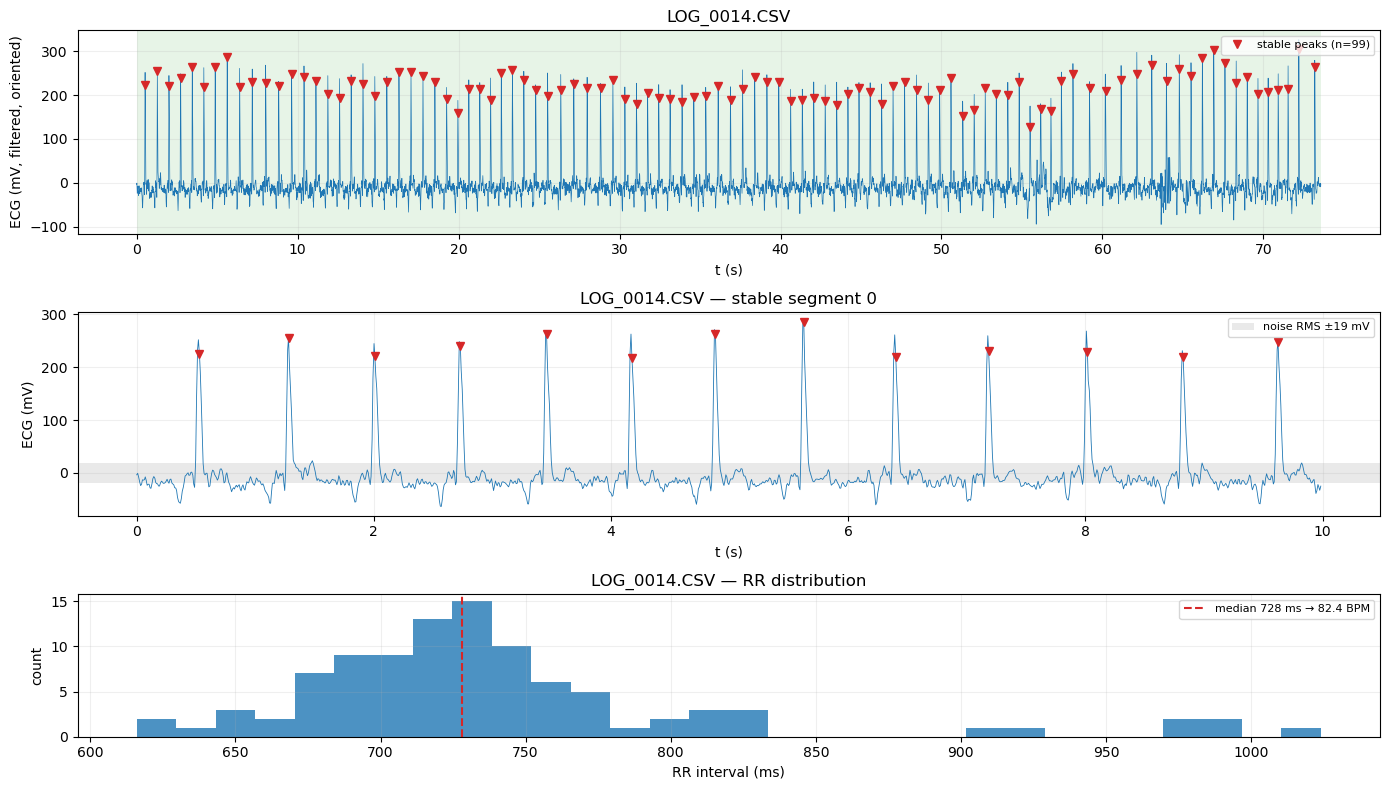

In [3]:
rec = Recording.from_csv(DATA_DIR / 'LOG_0014.CSV')
res = rec.analyze()
print(res.summary_dict())
plot_recording_full(res);

## 3. Long recording with manhandling — LOG_0013
5-minute run. The stable-region gate should highlight electrode-artefact segments and the peak detector should only score peaks inside stable regions.

{'file': 'LOG_0013.CSV', 'fs_hz': 125.0, 'duration_s': 288.7, 'polarity': -1, 'stable_frac': 0.895, 'n_peaks_total': 33, 'n_peaks_stable': 15, 'bpm_median': 67.3, 'bpm_mean': 73.3, 'sdnn_ms': 148.8, 'rmssd_ms': 164.0, 'noise_rms_mv': 21.4, 'peak_amp_mv': 73.9, 'snr_db': 10.8}


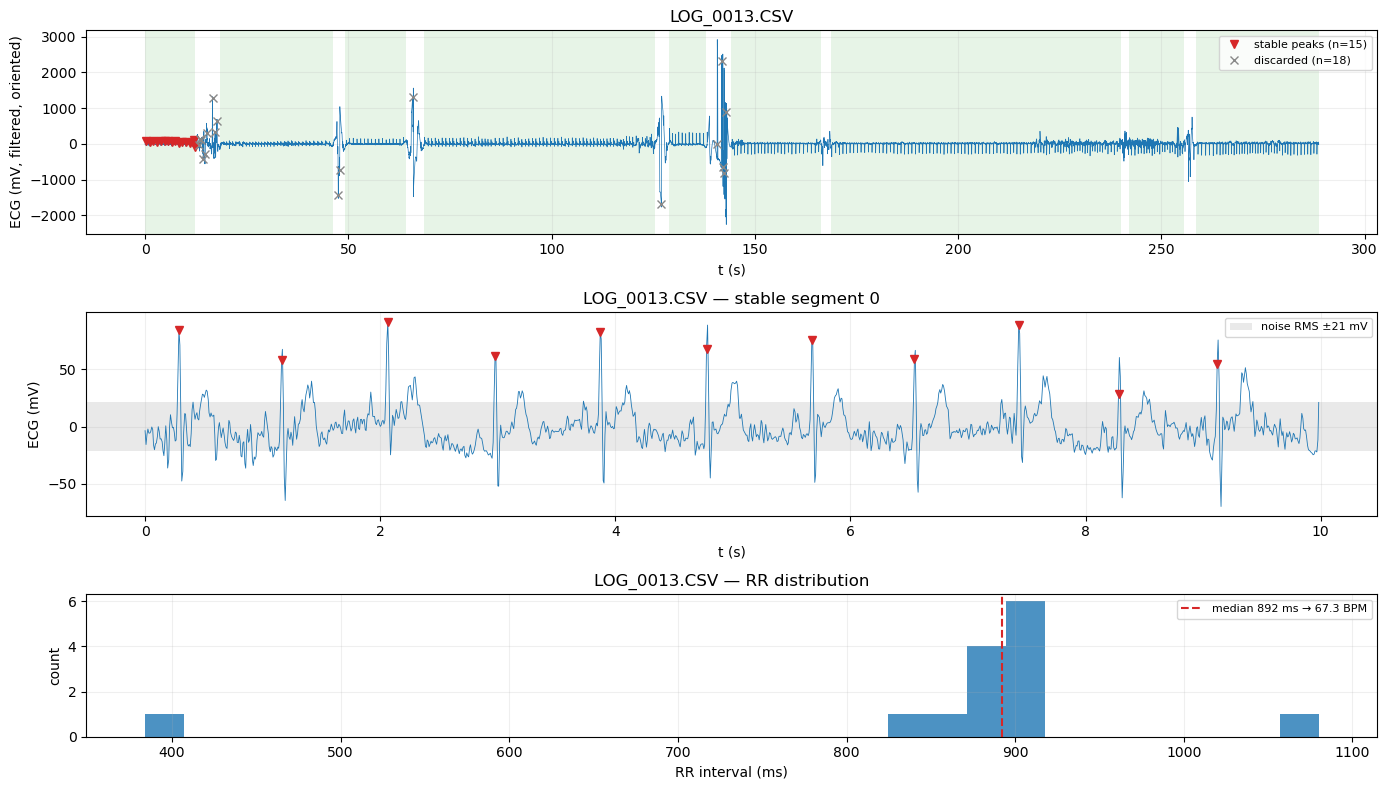

In [4]:
rec = Recording.from_csv(DATA_DIR / 'LOG_0013.CSV')
res = rec.analyze()
print(res.summary_dict())
plot_recording_full(res);

## 4. Inspect any single file with a helper

{'file': 'LOG_0015.CSV', 'fs_hz': 125.0, 'duration_s': 28.6, 'polarity': 1, 'stable_frac': 1.0, 'n_peaks_total': 44, 'n_peaks_stable': 44, 'bpm_median': 104.2, 'bpm_mean': 98.8, 'sdnn_ms': 220.6, 'rmssd_ms': 326.1, 'noise_rms_mv': 116.0, 'peak_amp_mv': 1022.0, 'snr_db': 18.9}


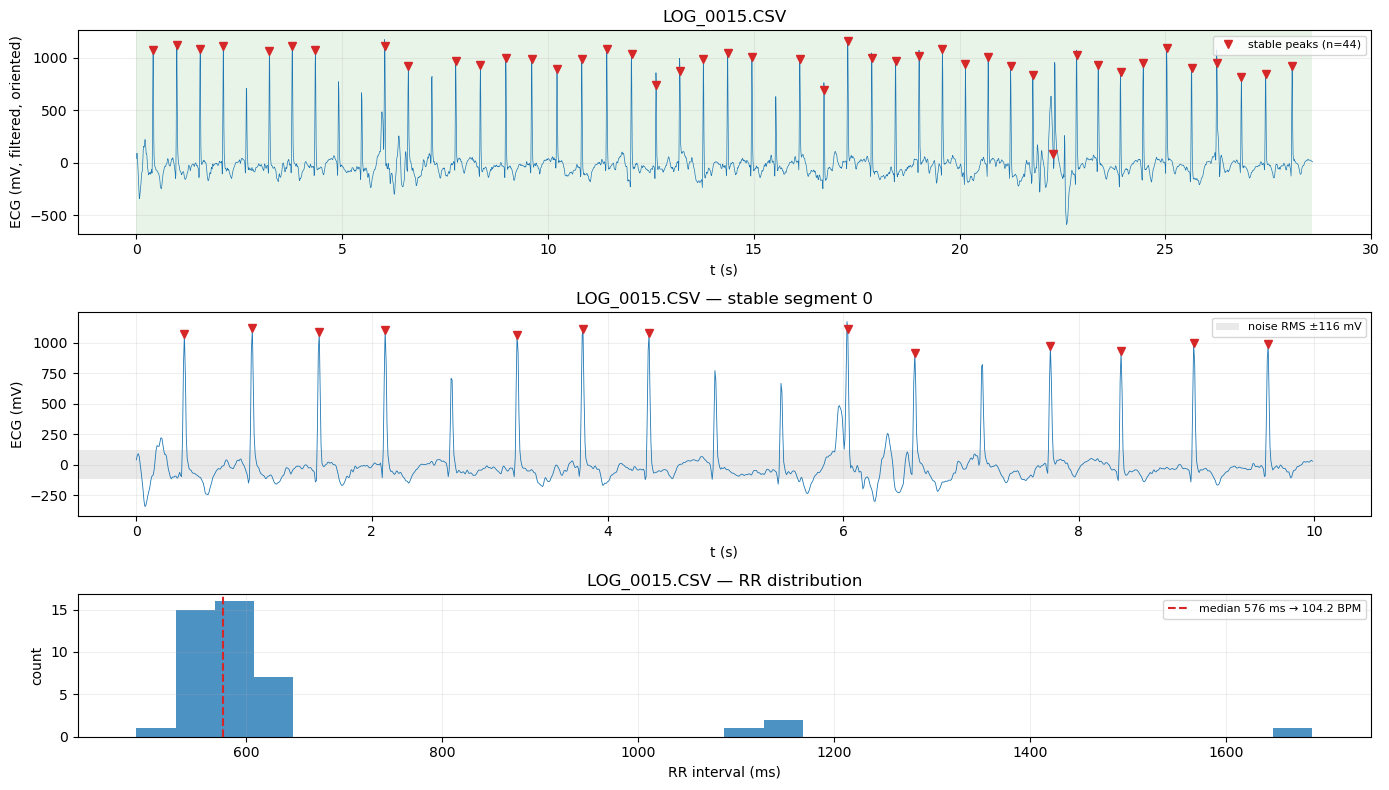

In [5]:
def inspect(name):
    rec = Recording.from_csv(DATA_DIR / name)
    res = rec.analyze()
    print(res.summary_dict())
    plot_recording_full(res)
    plt.show()
    return res

_ = inspect('LOG_0015.CSV')

## 5. Compare inter-file noise floor + SNR — sanity check
Solid recordings should cluster around noise ≈ 20 mV, SNR > 20 dB. Anything with noise > 100 mV was manhandling / bad contact.

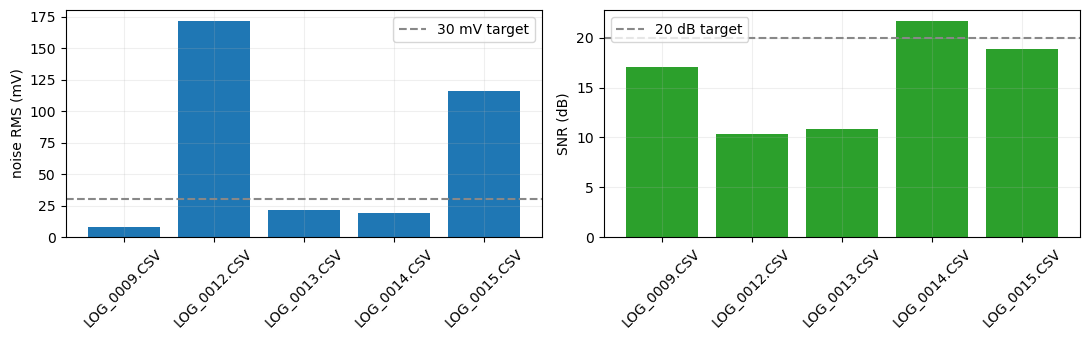

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ok = df.dropna(subset=['snr_db'])
ax[0].bar(ok['file'], ok['noise_rms_mv'], color='#1F77B4')
ax[0].set_ylabel('noise RMS (mV)')
ax[0].tick_params(axis='x', rotation=45)
ax[0].axhline(30, color='#888', ls='--', label='30 mV target')
ax[0].grid(alpha=0.2); ax[0].legend()
ax[1].bar(ok['file'], ok['snr_db'], color='#2CA02C')
ax[1].set_ylabel('SNR (dB)')
ax[1].tick_params(axis='x', rotation=45)
ax[1].axhline(20, color='#888', ls='--', label='20 dB target')
ax[1].grid(alpha=0.2); ax[1].legend()
fig.tight_layout();

## 6. Save summary CSV

In [7]:
out = DATA_DIR.parent / 'analysis_summary_2026-08-18.csv'
df.to_csv(out, index=False)
print('wrote', out)

wrote /home/ivan/Projekti/Elektronika/Srceko-ECG/ref_files/data/analysis_summary_2026-08-18.csv
